# **Business Understanding**

**Breast Cancer Wisconsin (Original)**
Samples arrive periodically as Dr. Wolberg reports his clinical cases. The database therefore reflects this chronological grouping of the data. This grouping information appears immediately below, having been removed from the data itself:

Group 1: 367 instances (January 1989)
Group 2:  70 instances (October 1989)
Group 3:  31 instances (February 1990)
Group 4:  17 instances (April 1990)
Group 5:  48 instances (August 1990)
Group 6:  49 instances (Updated January 1991)
Group 7:  31 instances (June 1991)
Group 8:  86 instances (November 1991)
-----------------------------------------
Total:   699 points (as of the donated datbase on 15 July 1992)

Note that the results summarized above in Past Usage refer to a dataset of size 369, while Group 1 has only 367 instances.  This is because it originally contained 369 instances; 2 were removed.  The following statements summarizes changes to the original Group 1's set of data:

#####  Group 1 : 367 points: 200B 167M (January 1989)

- #####  Revised Jan 10, 1991: Replaced zero bare nuclei in 1080185 & 1187805

- #####  Revised Nov 22,1991: Removed 765878,4,5,9,7,10,10,10,3,8,1 no record
- #####                  : Removed 484201,2,7,8,8,4,3,10,3,4,1 zero epithelial
- #####                  : Changed 0 to 1 in field 6 of sample 1219406
- #####                  : Changed 0 to 1 in field 8 of following sample:
- #####                  : 1182404,2,3,1,1,1,2,0,1,1,1

Has Missing Values? Yes

*Variables*
1. Sample code number:            id number
2. Clump Thickness:               1 - 10
3. Uniformity of Cell Size:       1 - 10
4. Uniformity of Cell Shape:      1 - 10
5. Marginal Adhesion:             1 - 10
6. Single Epithelial Cell Size:   1 - 10
7. Bare Nuclei:                   1 - 10
8. Bland Chromatin:               1 - 10
9. Normal Nucleoli:               1 - 10
10. Mitoses:                       1 - 10
11. Class:                        (2 for benign, 4 for malignant)

[Data Source](https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original)

#### **Loading Libraries**

In [69]:
import pandas as pd # data manipulation and reading the dat as a dataframe
import numpy as np # for numerical analysis 
import seaborn as sns # visualizations
from sklearn.model_selection import train_test_split # we split the data to use it well 
from sklearn.metrics import r2_score # evaluation metric  - R^2 
import matplotlib.pyplot as plt # aids in visualization
from sklearn.datasets import load_iris # preloaded data
from sklearn.linear_model import LogisticRegression # the model itself
from sklearn.preprocessing import StandardScaler # scaling towards a mean = 0 and sd = 1
from sklearn.metrics import classification_report

#### **Loading Data**

In [41]:
columns = [
    "ID",
    "Clump_thickness",
    "Uniformity_of_cell_size",
    "Uniformity_of_cell_shape",
    "Marginal_adhesion",
    "Single_epithelial_cell_size",
    "Bare_nuclei",
    "Bland_chromatin",
    "Normal_nucleoli",
    "Mitoses",
    "Diagnosis"
]

In [42]:
df = pd.read_csv("data/breast-cancer-wisconsin.data", header=None, names=columns)

Current features

In [43]:
df.head(3)

,ID,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Diagnosis
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2


# **Data Understanding**

In [40]:
rows, features = df.shape
print(f"Records: {rows} || Features: {features}")

Records: 699 || Features: 11


In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   ID                           699 non-null    int64
 1   Clump_thickness              699 non-null    int64
 2   Uniformity_of_cell_size      699 non-null    int64
 3   Uniformity_of_cell_shape     699 non-null    int64
 4   Marginal_adhesion            699 non-null    int64
 5   Single_epithelial_cell_size  699 non-null    int64
 6   Bare_nuclei                  699 non-null    str  
 7   Bland_chromatin              699 non-null    int64
 8   Normal_nucleoli              699 non-null    int64
 9   Mitoses                      699 non-null    int64
 10  Diagnosis                    699 non-null    int64
dtypes: int64(10), str(1)
memory usage: 60.2 KB


In [26]:
df['Bare_nuclei'].unique() # gets the unique values from the features

<StringArray>
['1', '10', '2', '4', '3', '9', '7', '?', '5', '8', '6']
Length: 11, dtype: str

Univariate Analysis

Bi-variate Analysis

Multi-variate Analysis

# **Data Preparation**

remove the '?' that exists in the column, 
The remedy of missing values is often dropping the row, when the number of missing values go beyond 70% we drop the entire column and if they are below 20% we trend to drop the missing row or perfomr imputation(you use an MCT to fill the missing values) => Investing Missing values the possibilities include: Missing at random, read this:[Handling missing values](https://www.datacamp.com/tutorial/techniques-to-handle-missing-data-values)

In [52]:
df['Bare_nuclei'] = df['Bare_nuclei'].replace('?', pd.NA)

In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   ID                           699 non-null    int64
 1   Clump_thickness              699 non-null    int64
 2   Uniformity_of_cell_size      699 non-null    int64
 3   Uniformity_of_cell_shape     699 non-null    int64
 4   Marginal_adhesion            699 non-null    int64
 5   Single_epithelial_cell_size  699 non-null    int64
 6   Bare_nuclei                  683 non-null    str  
 7   Bland_chromatin              699 non-null    int64
 8   Normal_nucleoli              699 non-null    int64
 9   Mitoses                      699 non-null    int64
 10  Diagnosis                    699 non-null    int64
dtypes: int64(10), str(1)
memory usage: 60.2 KB


since the missing values in 'Bare_nuclei' column are less than 2% we can drop the row

In [56]:
df['Bare_nuclei'] = pd.to_numeric(df['Bare_nuclei']) # converts to numerical form and reassigns the column 'Bare_nulcei' 
df = df.dropna() # dropping all rows containing the  missing values 

In [58]:
df.info()

<class 'pandas.DataFrame'>
Index: 683 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           683 non-null    int64  
 1   Clump_thickness              683 non-null    int64  
 2   Uniformity_of_cell_size      683 non-null    int64  
 3   Uniformity_of_cell_shape     683 non-null    int64  
 4   Marginal_adhesion            683 non-null    int64  
 5   Single_epithelial_cell_size  683 non-null    int64  
 6   Bare_nuclei                  683 non-null    float64
 7   Bland_chromatin              683 non-null    int64  
 8   Normal_nucleoli              683 non-null    int64  
 9   Mitoses                      683 non-null    int64  
 10  Diagnosis                    683 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 64.0 KB


2 for benign, 4 for malignant
map 2 -> 0  and 4 -> 1

In [45]:
df.head(1)

,ID,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Diagnosis
0,1000025,5,1,1,1,2,1,3,1,1,2


encoding, we are basically mapping th evalues of 2 -> 0 and 4 -> 1

In [46]:
df['Diagnosis'] = df['Diagnosis'].map({2:0, 4:1}) # simple encoding to binary form i.e 0 and 1

In [47]:
counts = df['Diagnosis'].value_counts().sort_index()
counts

Diagnosis
0    458
1    241
Name: count, dtype: int64

Visualization of the binary classes

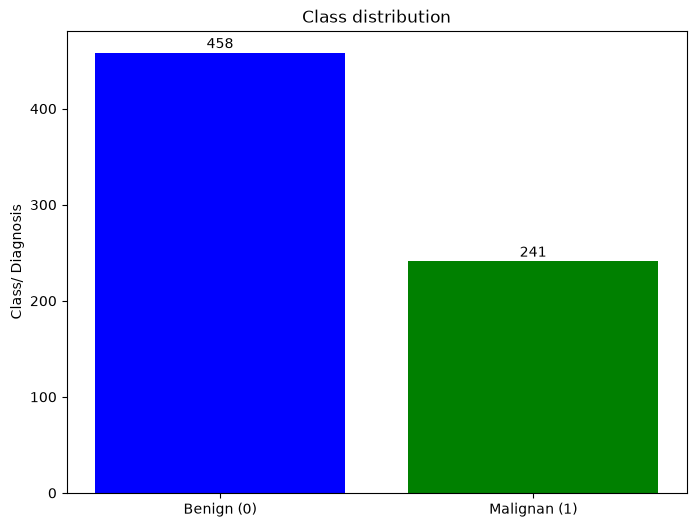

In [50]:
plt.figure(figsize=(8,6)) # usually manipulates the size
plt.bar(['Benign (0)','Malignan (1)'], counts.values, color=['blue', 'green'])
plt.title("Class distribution")
plt.ylabel('Number of samples')
plt.ylabel('Class/ Diagnosis')

for i, v in enumerate(counts.values):
    plt.text(i,v + 5, str(v), ha='center')

plt.show()

We notice that the 0 class (Benin) is more than  the 1 class (Malignant) 

splitting data

In [59]:
X = df.drop('Diagnosis', axis = 1)
y = df['Diagnosis']

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3, 
    random_state=42, 
    # stratify= y # it will retain a constant proportion when splitting the two classes
)

In [61]:
print(y_train.value_counts(normalize = True))
print(y_test.value_counts(normalize = True))


Diagnosis
0    0.66318
1    0.33682
Name: proportion, dtype: float64
Diagnosis
0    0.619512
1    0.380488
Name: proportion, dtype: float64


In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3, 
    random_state=42, 
    stratify= y # it will retain a constant proportion when splitting the two classes
)

In [64]:
#  stratified
print(y_train.value_counts(normalize = True))
print(y_test.value_counts(normalize = True))


Diagnosis
0    0.650628
1    0.349372
Name: proportion, dtype: float64
Diagnosis
0    0.64878
1    0.35122
Name: proportion, dtype: float64


# **Modeling**

StandardScaler - shifts and stretches each feature so it can have a mean =0 and standrad deviation of 1

In [ ]:
scaler = StandardScaler() #instance of the standard scaler

X_train_scaled = scaler.fit_transform(X_train) # calcluate the mean and standard deviation of each column(independent variables) stores them in a scaler

X_test_scaled =  scaler.transform(X_test) # applies the scaling formlar (x-mean)/std

In [ ]:
model = LogisticRegression() # instancen of the model 
model.fit(X_train_scaled, y_train) # trianed our model 

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [ ]:
y_hats = model.predict(X_test_scaled)
y_hats # predictions

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 0])

# **Evaluation**

In [71]:
print(classification_report(y_test, y_hats))

              precision    recall  f1-score   support

           0       0.97      0.96      0.97       133
           1       0.93      0.94      0.94        72

    accuracy                           0.96       205
   macro avg       0.95      0.95      0.95       205
weighted avg       0.96      0.96      0.96       205

